# Exploratory Data Analysis (EDA)

## 1. Introduction
This notebook focuses on the Exploratory Data Analysis (EDA). The dataset contains road traffic fatalities enriched with socio-economic indicators (GDP per capita, population, and alcohol consumption) for various countries (around 200 countries).

The primary target variable is `Death_Rate_Per_100k`, which corresponds to the annual number of traffic-related deaths per 100,000 people. By visualizing the data, the aim is to uncover patterns and relationships between economic development, cultural habits (alcohol consumption), and traffic safety.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for the notebook
sns.set_theme(style="whitegrid", palette="muted")

# Load the processed dataset
print("Loading the processed dataset...")
df = pd.read_csv('processed_dataset.csv')
display(df.head())

Loading the processed dataset...


,Country_Code,Year,Traffic_Deaths,Population,GDP_Per_Capita,Alcohol_Per_Capita,Death_Rate_Per_100k
0,AFG,2000,6581,20130327.0,174.930991,0.003,32.691968
1,AFG,2001,6720,20284307.0,138.706822,0.003,33.129059
2,AFG,2002,6696,21378117.0,178.954088,0.007,31.321748
3,AFG,2003,7243,22733049.0,198.871116,0.016,31.861102
4,AFG,2004,7522,23560654.0,221.763654,0.021,31.926109


## 1.1 Data Quality Check
Before diving into visual analysis, It is needed to verify the integrity of the dataset. I will check the shape, missing values, and ensure there are no duplicate `Country-Year` pairs.

In [12]:
print(f"Dataset Shape: {df.shape} (Observations, Features)")
print(f"Total Unique Countries: {df['Country_Code'].nunique()}")
print(f"Years Covered: {df['Year'].min()} to {df['Year'].max()}\n")

print("--- Missing Values ---")
print(df.isna().sum())

print("\n--- Duplicate Check ---")
duplicates = df.duplicated(['Country_Code', 'Year']).sum()
print(f"Duplicate Country-Year pairs: {duplicates}")

print("\n--- Data Types ---")
df.info()

Dataset Shape: (3677, 7) (Observations, Features)
Total Unique Countries: 186
Years Covered: 2000 to 2019

--- Missing Values ---
Country_Code           0
Year                   0
Traffic_Deaths         0
Population             0
GDP_Per_Capita         0
Alcohol_Per_Capita     0
Death_Rate_Per_100k    0
dtype: int64

--- Duplicate Check ---
Duplicate Country-Year pairs: 0

--- Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3677 entries, 0 to 3676
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Country_Code         3677 non-null   object 
 1   Year                 3677 non-null   int64  
 2   Traffic_Deaths       3677 non-null   int64  
 3   Population           3677 non-null   float64
 4   GDP_Per_Capita       3677 non-null   float64
 5   Alcohol_Per_Capita   3677 non-null   float64
 6   Death_Rate_Per_100k  3677 non-null   float64
dtypes: float64(4), int64(2), object(1)
memory us

## 2. Descriptive Statistics
Before creating charts, let's examine the central tendencies, spread, and extreme values of our numerical variables to understand the scale of the data as a whole.

In [13]:
# Generate summary statistics
summary_stats = df[['Population', 'GDP_Per_Capita', 'Alcohol_Per_Capita', 'Death_Rate_Per_100k']].describe()

# Displaying with 2 decimal points for better readability
display(summary_stats.round(2))

,Population,GDP_Per_Capita,Alcohol_Per_Capita,Death_Rate_Per_100k
count,3.677000e+03,3677.00,3677.00,3677.00
mean,3.742188e+07,11636.01,5.50,17.42
std,1.381198e+08,17506.65,4.20,10.78
min,9.544000e+03,109.59,0.00,2.95
25%,2.005330e+06,1209.73,1.77,9.97
50%,8.059500e+06,4062.22,4.95,15.17
75%,2.578848e+07,13573.23,8.68,21.59
max,1.407745e+09,123678.70,19.40,78.13


## 2.1 Why Normalize? (Raw Deaths vs. Population)
As stated, the primary metric is `Death_Rate_Per_100k` rather than absolute `Traffic_Deaths`. The scatter plot below demonstrates why the absolute traffic deaths are almost perfectly correlated with population size. Comparing raw deaths between a massive country like China and a small island nation would be highly misleading. Normalizing by population allows for fair cross-country comparisons.

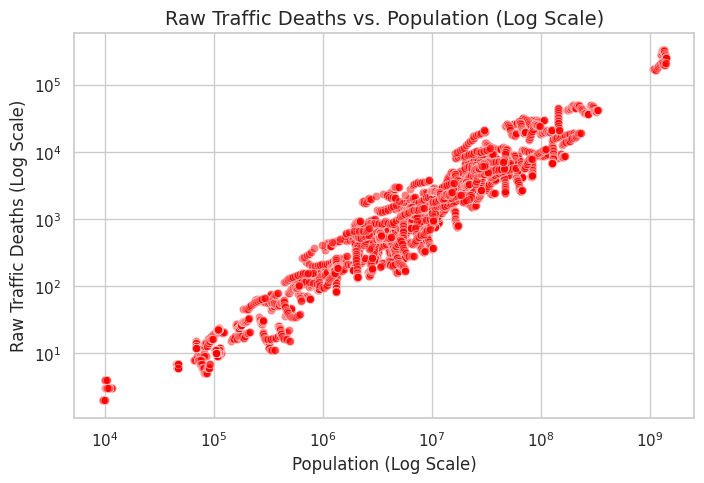

In [14]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Population', y='Traffic_Deaths', alpha=0.5, color='red')
plt.xscale('log')
plt.yscale('log')
plt.title('Raw Traffic Deaths vs. Population (Log Scale)', fontsize=14)
plt.xlabel('Population (Log Scale)')
plt.ylabel('Raw Traffic Deaths (Log Scale)')
plt.show()

## 2.2 Data Distributions (Checking for Skewness)
Understanding the distribution of the variables is crucial for selecting the right statistical tests later. As seen below, all the variables (`Death_Rate_Per_100k`, `GDP`, `Alcohol`) are highly right-skewed. This indicates that we should rely on non-parametric tests (like Spearman correlation) rather than parametric ones (like Pearson) during our hypothesis testing phase. But I will show both of these tests' results later, just in case.

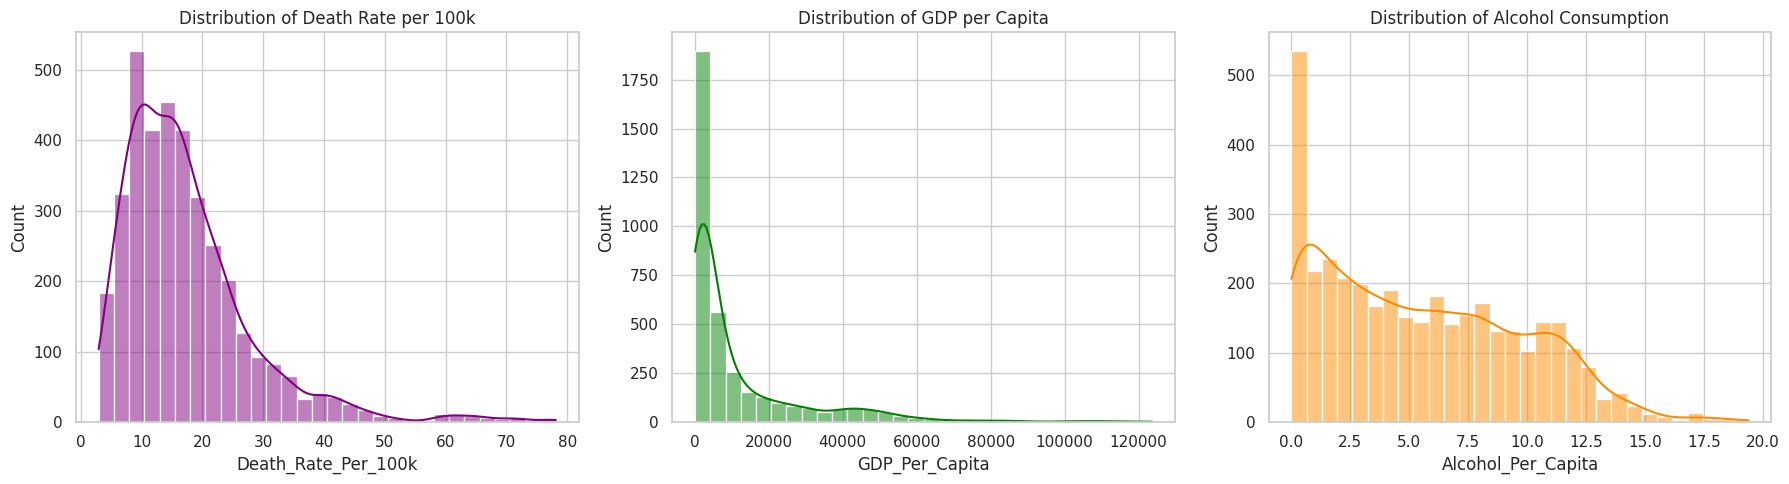

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['Death_Rate_Per_100k'], kde=True, ax=axes[0], color='purple', bins=30) # Purple palette for Death Rate
axes[0].set_title('Distribution of Death Rate per 100k')

sns.histplot(df['GDP_Per_Capita'], kde=True, ax=axes[1], color='green', bins=30) # Green palette for GDP
axes[1].set_title('Distribution of GDP per Capita')

sns.histplot(df['Alcohol_Per_Capita'], kde=True, ax=axes[2], color='darkorange', bins=30) # Orange palette for Alcohol
axes[2].set_title('Distribution of Alcohol Consumption')

plt.tight_layout()
plt.show()

## 3. Correlation Analysis
To understand the linear relationships between all the numeric variables at once, I will generate a correlation matrix and visualize it using a heatmap.

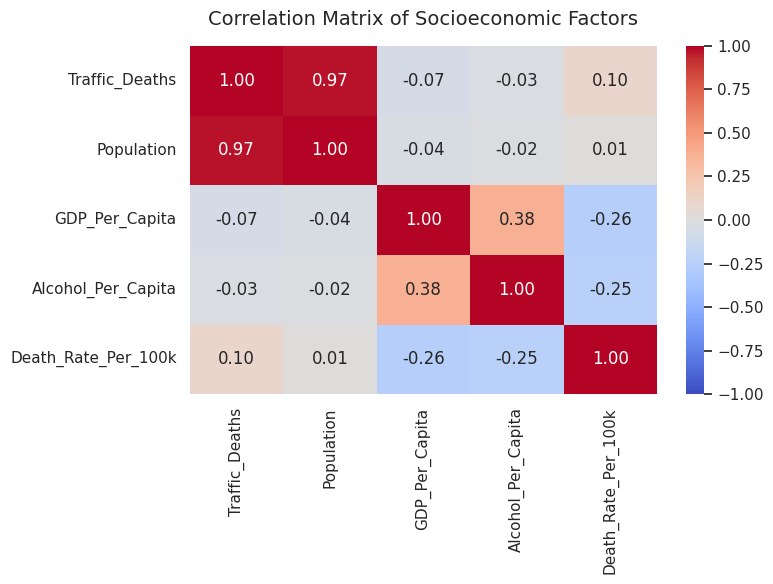

In [16]:
plt.figure(figsize=(8, 6))

# Select only the numeric columns for correlation
numeric_cols = ['Traffic_Deaths', 'Population', 'GDP_Per_Capita', 'Alcohol_Per_Capita', 'Death_Rate_Per_100k']
corr_matrix = df[numeric_cols].corr()

# Create the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Matrix of Socioeconomic Factors', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

## 4. Visualizing Key Relationships
Based on the project goals, Let's look at three specific relationships using scatter plots with regression lines:
1. **Economic Impact:** How does GDP per capita affect traffic death rates? (Using a log scale for GDP).
2. **Behavioral Impact:** Is there a visible trend between alcohol consumption and traffic death rates?
3. **Demographic Impact:** Does the total population size of a country correlate with its traffic death rate? (Using a log scale for Population).

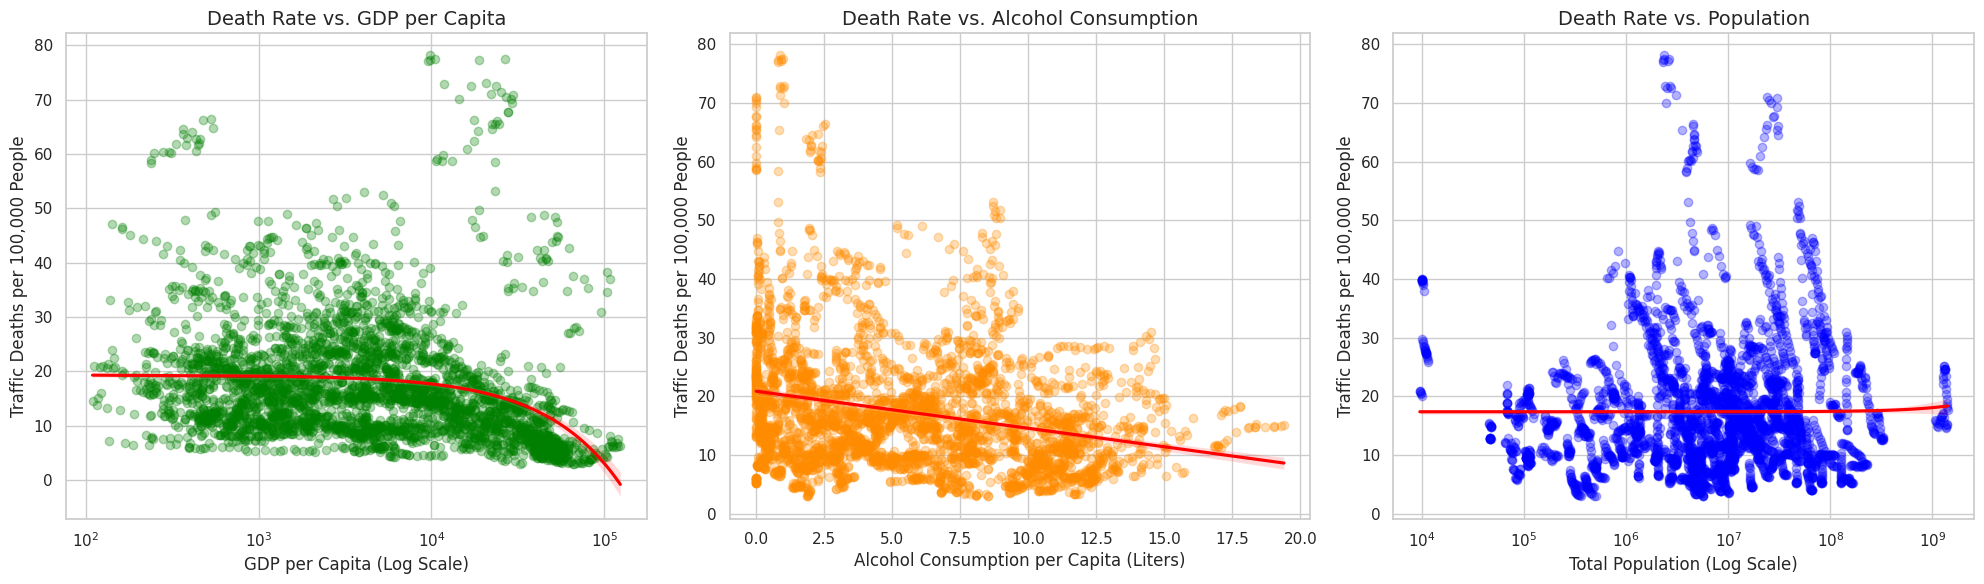

In [17]:
# creating a figure with 3 subplots side by side
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: GDP vs Death Rate
sns.regplot(ax=axes[0], x='GDP_Per_Capita', y='Death_Rate_Per_100k', data=df,
            scatter_kws={'alpha':0.3, 'color':'green'}, line_kws={'color':'red'}) # Green palette for GDP
axes[0].set_xscale('log') # Log scale for GDP
axes[0].set_title('Death Rate vs. GDP per Capita', fontsize=14)
axes[0].set_xlabel('GDP per Capita (Log Scale)', fontsize=12)
axes[0].set_ylabel('Traffic Deaths per 100,000 People', fontsize=12)

# Plot 2: Alcohol vs Death Rate
sns.regplot(ax=axes[1], x='Alcohol_Per_Capita', y='Death_Rate_Per_100k', data=df,
            scatter_kws={'alpha':0.3, 'color': 'darkorange'}, line_kws={'color':'red'}) # Orange palette for Alcohol
axes[1].set_title('Death Rate vs. Alcohol Consumption', fontsize=14)
axes[1].set_xlabel('Alcohol Consumption per Capita (Liters)', fontsize=12)
axes[1].set_ylabel('Traffic Deaths per 100,000 People', fontsize=12)

# Plot 3: Population vs Death Rate
sns.regplot(ax=axes[2], x='Population', y='Death_Rate_Per_100k', data=df,
            scatter_kws={'alpha':0.3, 'color': 'blue'}, line_kws={'color':'red'}) # Blue palette for Population
axes[2].set_xscale('log') # Log scale for Population
axes[2].set_title('Death Rate vs. Population', fontsize=14)
axes[2].set_xlabel('Total Population (Log Scale)', fontsize=12)
axes[2].set_ylabel('Traffic Deaths per 100,000 People', fontsize=12)

plt.tight_layout()
plt.show()

## 5. Temporal Trends (Time Series Analysis)
To understand the global trajectory, I will calculate the worldwide average for each year and visualize how these three main variables (`Death_Rate_Per_100k`, `GDP_Per_Capita`, and `Alcohol_Per_Capita`) have evolved over the last two decades. I will use scatter points with a linear trend line to easily spot the overall direction.

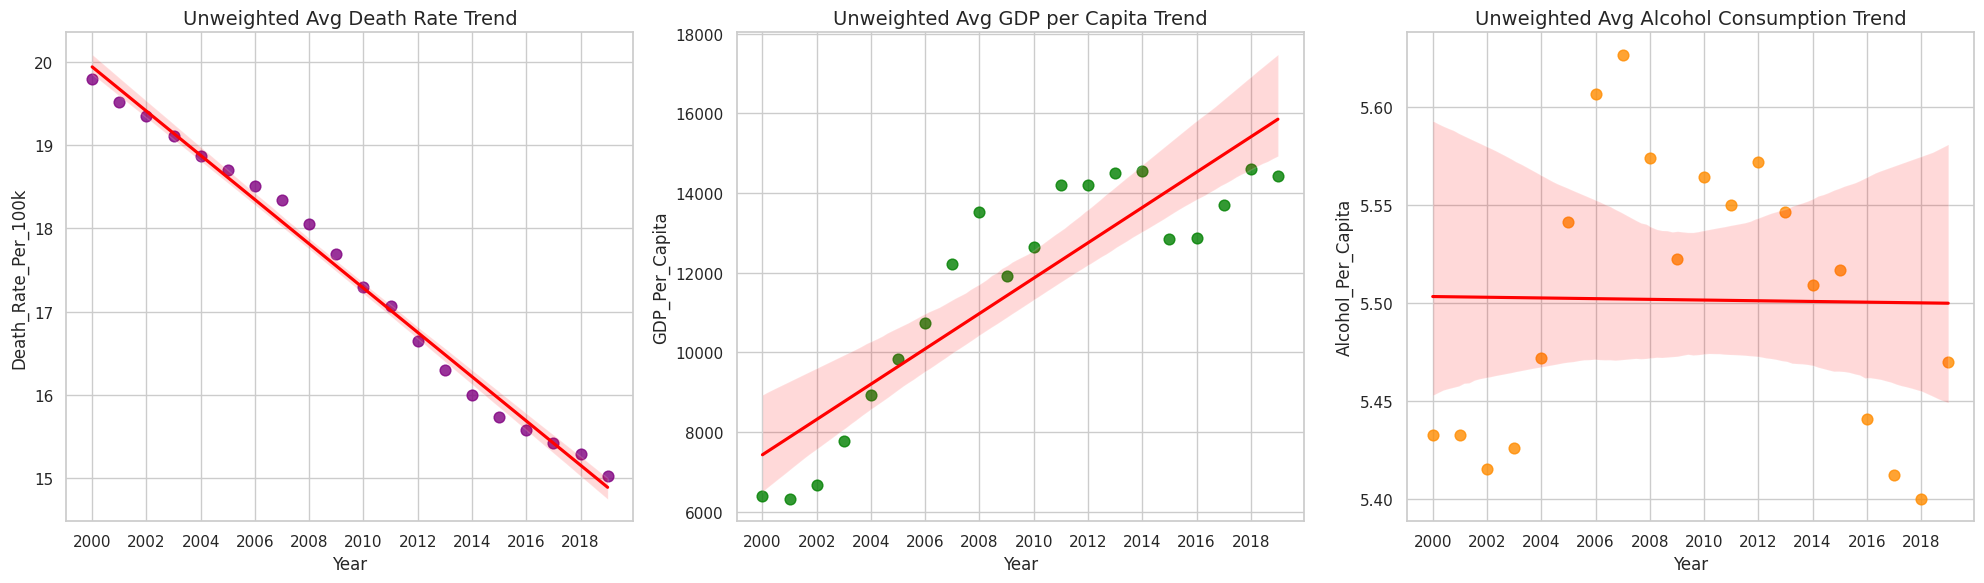

In [18]:
# Calculate the country-level average for each year (Unweighted)
yearly_avg = df.groupby('Year')[['Death_Rate_Per_100k', 'GDP_Per_Capita', 'Alcohol_Per_Capita']].mean().reset_index()

# Create a 3-panel figure
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Death Rate Trend
sns.regplot(ax=axes[0], x='Year', y='Death_Rate_Per_100k', data=yearly_avg,
            scatter_kws={'s': 60, 'color': 'purple'}, line_kws={'color': 'red'}) # Purple palette for Death Rate
axes[0].set_title('Unweighted Avg Death Rate Trend', fontsize=14)
axes[0].set_xticks(np.arange(df['Year'].min(), df['Year'].max() + 1, 2))

# GDP Trend
sns.regplot(ax=axes[1], x='Year', y='GDP_Per_Capita', data=yearly_avg,
            scatter_kws={'s': 60, 'color': 'green'}, line_kws={'color': 'red'}) # Green palette for GDP
axes[1].set_title('Unweighted Avg GDP per Capita Trend', fontsize=14)
axes[1].set_xticks(np.arange(df['Year'].min(), df['Year'].max() + 1, 2))

# Alcohol Trend
sns.regplot(ax=axes[2], x='Year', y='Alcohol_Per_Capita', data=yearly_avg,
            scatter_kws={'s': 60, 'color': 'darkorange'}, line_kws={'color': 'red'}) # Orange palette for Alcohol
axes[2].set_title('Unweighted Avg Alcohol Consumption Trend', fontsize=14)
axes[2].set_xticks(np.arange(df['Year'].min(), df['Year'].max() + 1, 2))

plt.tight_layout()
plt.show()

## 5. Categorical Analysis: Income and Alcohol Groups (Boxplots)
To conclude the Exploratory Data Analysis, Let's examine the variables from a categorical perspective. I will divide the countries into three distinct tiers: **Low**, **Medium**, and **High**.

**Methodology for Categorization:**
To ensure a fair comparison without arbitrary cutoffs, I used statistical **tertiles** (`pd.qcut` with `q=3`). This method sorts the countries and divides them into three equal-sized groups (33.3% of the dataset in each).
* **For Income:** The bottom 33% of countries by GDP are labeled 'Low Income', the middle 33% 'Medium Income', and the top 33% 'High Income'.
* **For Alcohol:** The same percentile-based logic is applied to alcohol consumption.

Using boxplots allows us to clearly observe the medians, spread, and outliers of traffic death rates across these different socio-economic tiers.

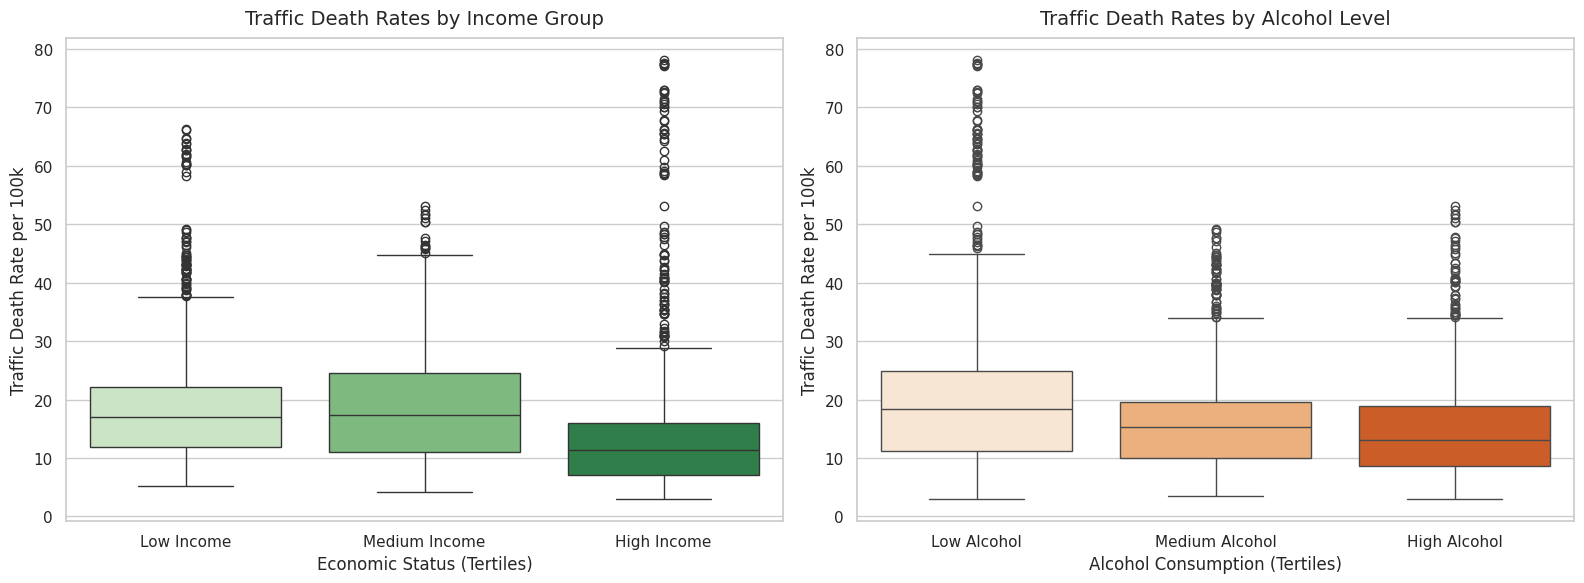

In [19]:
# categorizing countries into 3 equal-sized groups. (tertiles)
df['Income_Group'] = pd.qcut(df['GDP_Per_Capita'], q=3, labels=['Low Income', 'Medium Income', 'High Income'])
df['Alcohol_Group'] = pd.qcut(df['Alcohol_Per_Capita'], q=3, labels=['Low Alcohol', 'Medium Alcohol', 'High Alcohol'])

# defining custom color palettes (Light to Dark).
gdp_palette = ["#c7e9c0", "#74c476", "#238b45"] # Green palette for GDP
alc_palette = ["#fee6ce", "#fdae6b", "#e6550d"] # Orange palette for Alcohol

# creating a figure with 2 subplots side by side.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Death Rate by Income Group
sns.boxplot(ax=axes[0], data=df, x='Income_Group', y='Death_Rate_Per_100k',
            hue='Income_Group', palette=gdp_palette, legend=False)
axes[0].set_title('Traffic Death Rates by Income Group', fontsize=14, pad=10)
axes[0].set_ylabel('Traffic Death Rate per 100k', fontsize=12)
axes[0].set_xlabel('Economic Status (Tertiles)', fontsize=12)

# Plot 2: Death Rate by Alcohol Group
sns.boxplot(ax=axes[1], data=df, x='Alcohol_Group', y='Death_Rate_Per_100k',
            hue='Alcohol_Group', palette=alc_palette, legend=False)
axes[1].set_title('Traffic Death Rates by Alcohol Level', fontsize=14, pad=10)
axes[1].set_ylabel('Traffic Death Rate per 100k', fontsize=12)
axes[1].set_xlabel('Alcohol Consumption (Tertiles)', fontsize=12)

# adjust layout and display part.
plt.tight_layout()
plt.show()

## 6. Summary & Limitations

### Key Findings:
1. **Normalization is crucial:** Raw traffic fatalities are heavily dependent on population size, obviously.  `Death_Rate_Per_100k` provides a standardized metric for comparison.
2. **Economic impact:** Higher GDP per capita is associated with lower traffic death rates.
3. **Behavioral impact:** Alcohol consumption shows a moderate negative association with death rates, but this is likely masked by the confounding effect of GDP (wealthy countries consume more alcohol but have safer roads).
4. **Temporal improvement:** The unweighted cross-country average of death rates has noticeably decreased from 2000 to 2019.

### Methodological Limitations:
* **Correlation $\neq$ Causation:** The associations observed in this EDA do not imply direct causality.
* **Panel Data Structure:** The dataset contains repeated observations for the same countries over 20 years. Treating these as independent observations in simple tests can be misleading due to autocorrelation.